In [228]:
import pandas as pd
s1 = pd.Series([1,2,3,4])
s2 = pd.Series([5,6,7])
s3 = pd.Series([8,9,10,11])

keys1 = ["a", "b", "c"]
values1 = [1, 2, 3]


keys2 = ["s","t","u"]
values2 = [5,6,7]


keys3 = ["a","b","c","d"]
values3 = [8,9,10,11]


lista = [keys1, values1, keys2, values2, keys3, values3]

df = pd.DataFrame(lista, columns = ["s","t","u","v"])
index1 = pd.Index(["foo", "foo", "bar", "bar","a","b"])
index2 = pd.Index(["a","b","c","d"])

list(map(lambda x : x>1, values1))

[False, True, True]

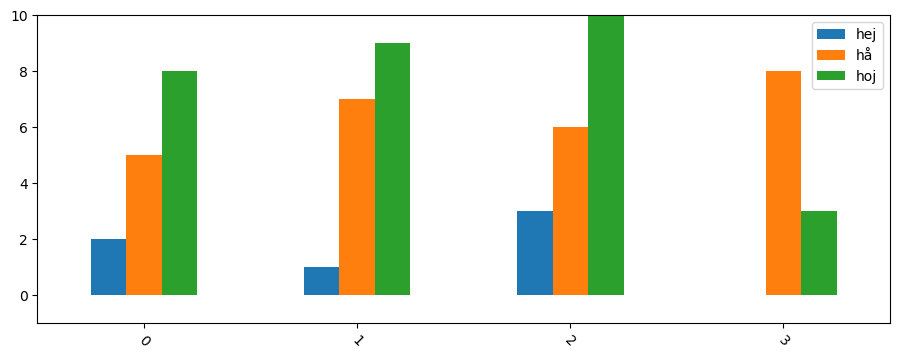

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
s1 = pd.Series([1,2,3,4])
s2 = pd.Series([5,6,7])
s3 = pd.Series([8,9,10,11])

dict1 = {"hej":s1, "hå":s2, "hoj":s3}

df=pd.DataFrame(dict1)


s1 = pd.Series([2,1,3,0])
s2 = pd.Series([5,7,6,8])
s3 = pd.Series([8,9,10,3])

dict1 = {"hej":s1, "hå":s2, "hoj":s3}

df1=pd.DataFrame(dict1)

df1
fig,ax = plt.subplots(figsize=(11,4)) #To change the size of the plot
df1.plot(ax=ax, kind="bar")
plt.ylim(-1,10) #To zoom in on the tops of the bars
plt.xticks(rotation=315) #rotating the titles
plt.show()

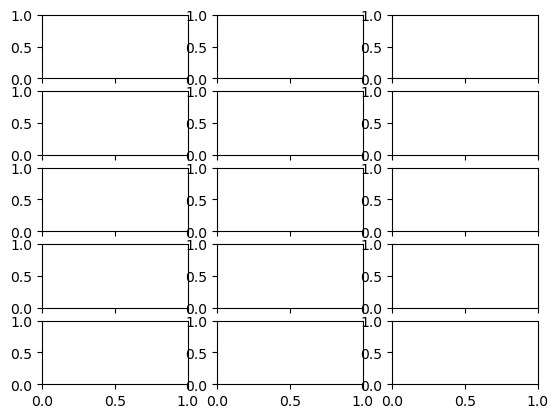

In [161]:
fig, axes = plt.subplots(nrows=5, ncols=3, sharex = True)

Text(1, 4, 'Hello world!')

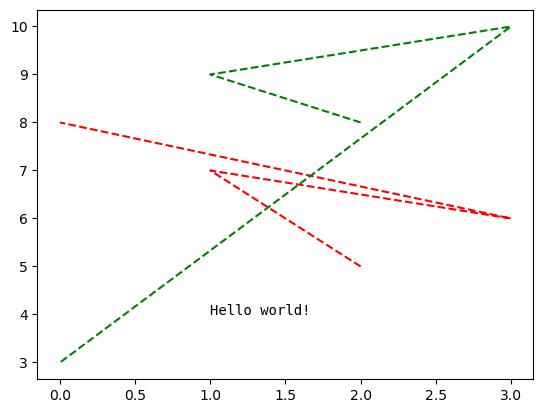

In [187]:
import numpy as np

plt.plot(s1, s2, linestyle="--", color="red");
plt.plot(s1, s3, linestyle="--", color="green");
plt.text(1, 4, "Hello world!", family="monospace", fontsize=10)

<Axes: title={'center': 'Exempelplot'}>

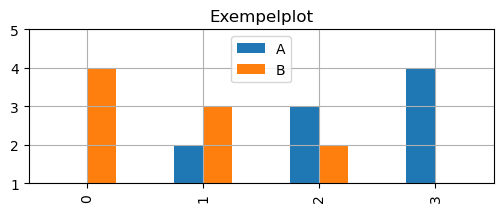

In [193]:
data = {
    "A": [1, 2, 3, 4],
    "B": [4, 3, 2, 1]
}
df = pd.DataFrame(data)

# Använd argumenten
df.plot(kind="bar", figsize=(6, 2), title="Exempelplot", grid=True, xlim=(0, 3), ylim=(1, 5))

#s1.plot(kind="bar", figsize=(6, 4), title="Exempelplot", grid=True, xlim=(0, 3), ylim=(1, 5))

In [194]:
df.isna()

,A,B
0,False,False
1,False,False
2,False,False
3,False,False


In [225]:
import pandas as pd
import numpy as np

# Skapa en DataFrame med NaN-värden
df = pd.DataFrame({
    'A': [1, np.nan, np.nan, np.nan, 3],
    'B': [np.nan, 4, np.nan, 5, np.nan],
    'C': [6, np.nan, 7, np.nan, 8]
})

# Använd 'ffill' med limit=2
df.replace([np.nan,3], 5.0)

,A,B,C
0,1.0,5.0,6.0
1,5.0,4.0,5.0
2,5.0,5.0,7.0
3,5.0,5.0,5.0
4,5.0,5.0,8.0


In [236]:
from bs4 import BeautifulSoup
import requests

upc_list = []
title_list = []
price_list = []
rating_list = []

def extract_book_info(book):
    book_url = book.h3.a["href"]
    r = requests.get(f"https://books.toscrape.com/catalogue/{book_url}")
    html = BeautifulSoup(r.content)

    upc = html.find('table', class_ = 'table table-striped').tr.td.text
    upc_list.append(upc)
    
    title = html.find('div', class_ = 'col-sm-6 product_main').h1.text
    title_list.append(title)

    price = html.find('p', class_ = 'price_color').text
    price_list.append(price)
    
    rating = html.find('p', class_ = 'star-rating')['class'][1]
    rating_list.append(rating)

url = "https://books.toscrape.com/catalogue/page-{}.html"
for page in range(1,4):
    r = requests.get(url.format(page))
    html = BeautifulSoup(r.content)
    for book in list(html.find_all("article")):
        extract_book_info(book)

df = pd.DataFrame({'upc':upc_list, 'title':title_list, 'price':price_list, 'rating':rating_list})
df.head(5)

,upc,title,price,rating
0,a897fe39b1053632,A Light in the Attic,£51.77,Three
1,90fa61229261140a,Tipping the Velvet,£53.74,One
2,6957f44c3847a760,Soumission,£50.10,One
3,e00eb4fd7b871a48,Sharp Objects,£47.82,Four
4,4165285e1663650f,Sapiens: A Brief History of Humankind,£54.23,Five
